In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:
df = pd.read_csv(r'C:\K\social-media-dev-crawler\data\Lda\classified_posts.csv')
df = df[df['type'] == 'question']

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1341 entries, 0 to 19018
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   site_alias             1341 non-null   object 
 1   tags                   1341 non-null   object 
 2   question_id            1341 non-null   int64  
 3   accepted_answer_id     972 non-null    float64
 4   answer_count           1341 non-null   float64
 5   creation_date          1341 non-null   object 
 6   last_activity_date     1341 non-null   object 
 7   last_edit_date         1073 non-null   object 
 8   owner_id               1292 non-null   float64
 9   score                  1341 non-null   int64  
 10  view_count             1341 non-null   float64
 11  comment_count          1341 non-null   float64
 12  title                  1341 non-null   object 
 13  body                   1341 non-null   object 
 14  site                   1341 non-null   object 
 15  id      

In [17]:
df['creation_date']

0        2008-09-23T22:32:27.737
1        2008-10-08T18:20:25.297
2        2008-10-14T17:07:32.963
3        2008-10-29T15:44:47.373
4        2008-11-03T15:31:13.293
                  ...           
19014    2016-04-15T16:55:33.817
19015    2016-03-21T05:20:32.623
19016    2019-05-08T16:19:28.510
19017    2020-06-03T01:04:26.183
19018    2021-06-08T18:15:25.287
Name: creation_date, Length: 1341, dtype: object

Total de tópicos: 15


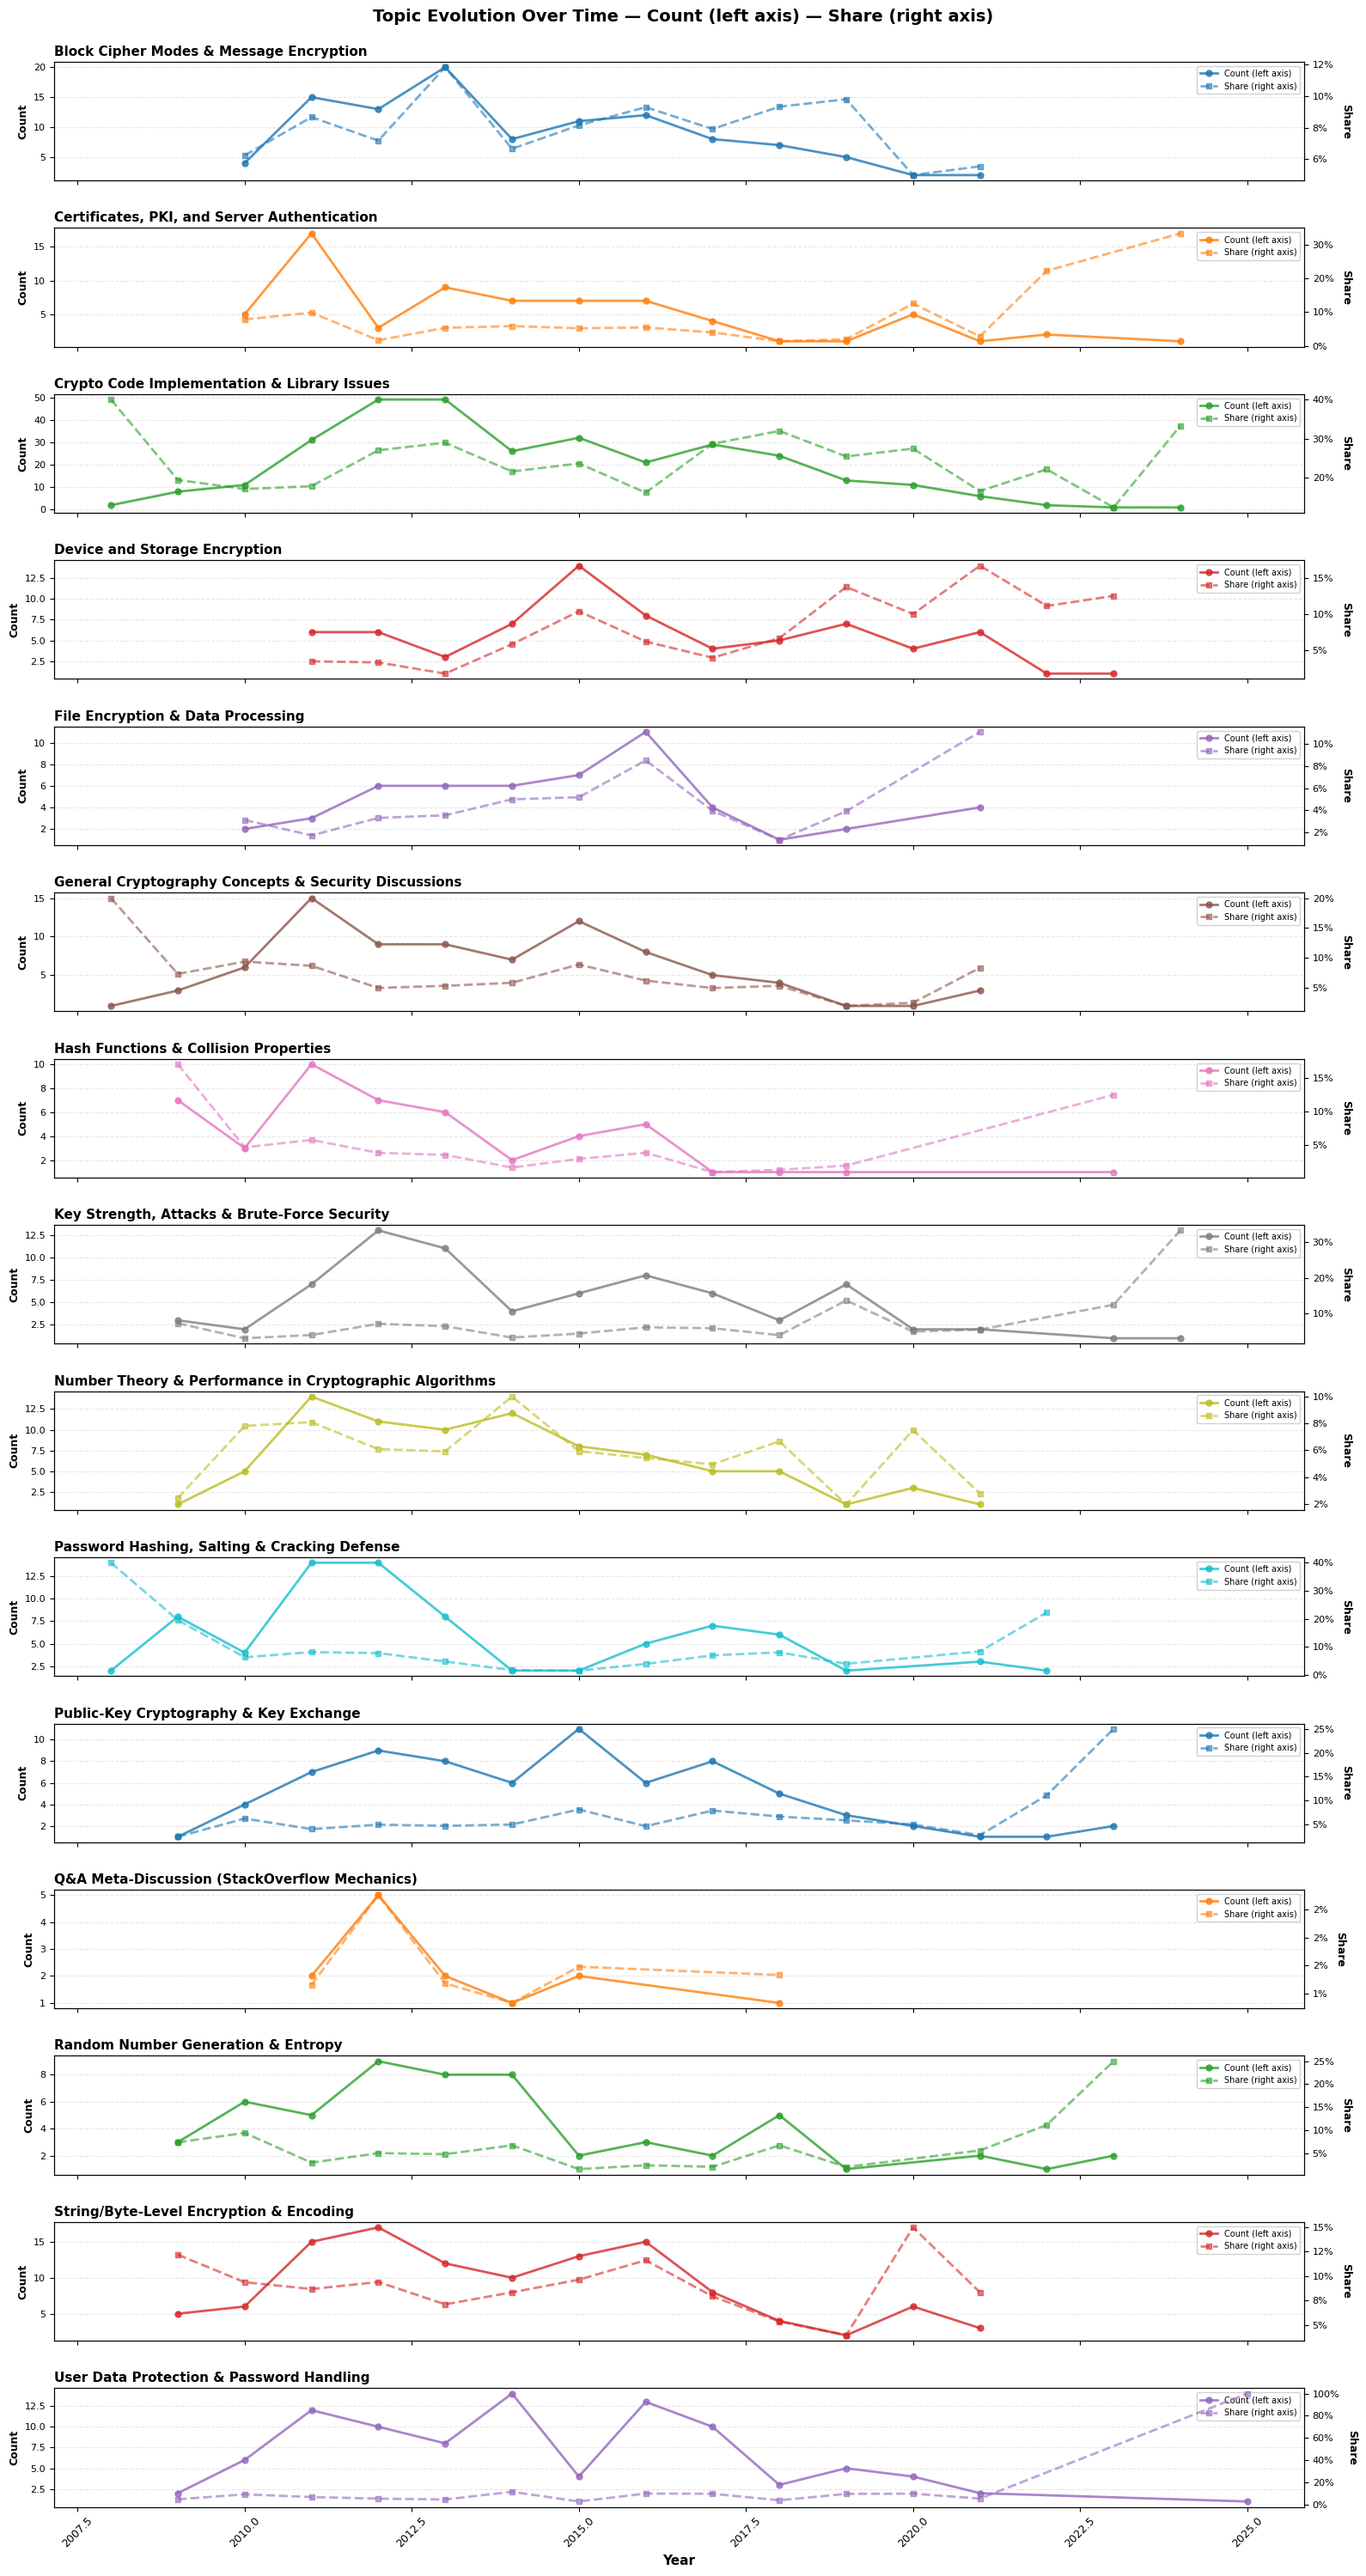


=== ESTATÍSTICAS POR TÓPICO ===

Block Cipher Modes & Message Encryption:
  Total de posts: 107
  Share geral: 8.0%
  Anos ativos: 12

Certificates, PKI, and Server Authentication:
  Total de posts: 70
  Share geral: 5.2%
  Anos ativos: 14

Crypto Code Implementation & Library Issues:
  Total de posts: 316
  Share geral: 23.6%
  Anos ativos: 17

Device and Storage Encryption:
  Total de posts: 72
  Share geral: 5.4%
  Anos ativos: 13

File Encryption & Data Processing:
  Total de posts: 52
  Share geral: 3.9%
  Anos ativos: 11

General Cryptography Concepts & Security Discussions:
  Total de posts: 84
  Share geral: 6.3%
  Anos ativos: 14

Hash Functions & Collision Properties:
  Total de posts: 48
  Share geral: 3.6%
  Anos ativos: 12

Key Strength, Attacks & Brute-Force Security:
  Total de posts: 76
  Share geral: 5.7%
  Anos ativos: 15

Number Theory & Performance in Cryptographic Algorithms:
  Total de posts: 83
  Share geral: 6.2%
  Anos ativos: 13

Password Hashing, Salting & C

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Converter creation_date para datetime se necessário
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# Extrair o ano
df['year'] = df['creation_date'].dt.year

# Agrupar por ano e tópico, contar ocorrências
topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')

# Calcular total de posts por ano
total_by_year = df.groupby('year').size().reset_index(name='total')

# Merge para calcular porcentagem
topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

# Obter todos os tópicos únicos
all_topics = sorted(df['topic'].unique())
n_topics = len(all_topics)

print(f"Total de tópicos: {n_topics}")

# Criar figura com subplots para todos os tópicos
fig, axes = plt.subplots(n_topics, 1, figsize=(16, 2 * n_topics), sharex=True)

# Garantir que axes seja sempre uma lista
if n_topics == 1:
    axes = [axes]

# Definir cores para cada tópico
colors = plt.cm.tab10(range(10))

# Criar um gráfico para cada tópico
for idx, topic in enumerate(all_topics):
    ax = axes[idx]
    
    # Criar eixo secundário para porcentagem
    ax2 = ax.twinx()
    
    # Filtrar dados do tópico
    topic_data = topic_by_year[topic_by_year['topic'] == topic].sort_values('year')
    
    if not topic_data.empty:
        color = colors[idx % 10]
        
        # Plotar contagem (linha sólida)
        line1 = ax.plot(topic_data['year'], topic_data['count'], 
                        marker='o', linewidth=2, markersize=5, 
                        color=color, label='Count (left axis)',
                        linestyle='-', alpha=0.8)
        
        # Plotar porcentagem (linha tracejada)
        line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                         marker='s', linewidth=2, markersize=4,
                         color=color, label='Share (right axis)',
                         linestyle='--', alpha=0.6)
    
    # Configurar eixo esquerdo (contagem)
    ax.set_ylabel('Count', fontsize=9, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Configurar eixo direito (porcentagem)
    ax2.set_ylabel('Share', fontsize=9, fontweight='bold', rotation=270, labelpad=15)
    ax2.tick_params(axis='y', labelsize=8)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    
    # Título do tópico
    ax.set_title(f'{topic}', fontsize=11, fontweight='bold', loc='left', pad=5)
    
    # Remover label do eixo x de todos exceto o último
    if idx < n_topics - 1:
        ax.tick_params(labelbottom=False)
    
    # Adicionar legenda pequena
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Count (left axis)', 'Share (right axis)'], 
              loc='upper right', fontsize=7, framealpha=0.9)

# Configurar o eixo x apenas no último subplot
axes[-1].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=9, rotation=45)

# Ajustar layout
plt.suptitle('Topic Evolution Over Time — Count (left axis) — Share (right axis)', 
             fontsize=14, fontweight='bold', y=0.998)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

# Estatísticas resumidas
print("\n=== ESTATÍSTICAS POR TÓPICO ===")
for topic in all_topics:
    topic_total = topic_by_year[topic_by_year['topic'] == topic]['count'].sum()
    overall_total = df.shape[0]
    topic_share = (topic_total / overall_total) * 100
    
    print(f"\n{topic}:")
    print(f"  Total de posts: {topic_total}")
    print(f"  Share geral: {topic_share:.1f}%")
    print(f"  Anos ativos: {topic_by_year[topic_by_year['topic'] == topic]['year'].nunique()}")